<i>So far each model was trained once with default settings, so the comparison wasn't fair. This notebook gives every candidate model a proper hyperparameter search under the same cross-validation scheme, selects the winner by PR-AUC (the right metric for a ~3.4% imbalance), tunes its decision threshold instead of using the default 0.5 cutoff, and then saves everything needed to deploy it (model, scaler, encoder, chosen threshold) as one bundle. That bundle is what the FastAPI service will load later. </i>

## <b>Part 1 Estimating the Best Model</b>
Comparing candidate models with a fair, shared hyperparameter search to identify the strongest performer by PR-AUC.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")

X_train = pd.read_csv('X_train_balanced.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train_balanced.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

<b>Giving each candidate model realistic Hyperparameters rather than defaults </b>

This is done for better comparison.

In [22]:
param_distributions = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300, 400],
            'max_depth': [None, 5, 10, 15, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [2, 3, 4, 5],
            'subsample': [0.7, 0.85, 1.0]
        }
    }
}

In [23]:
search_results = {}
fitted_models = {}

for name, config in param_distributions.items():
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=25,
        scoring='average_precision',
        cv=cv,
        random_state=42,
        n_jobs=-1 )
    search.fit(X_train, y_train)

    fitted_models[name] = search.best_estimator_
    search_results[name] = {
        'best_cv_pr_auc': search.best_score_,
        'best_params': search.best_params_
    }
    print(f"{name} done. Best CV PR-AUC: {search.best_score_:.4f}")

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=25. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression done. Best CV PR-AUC: 0.9069
Random Forest done. Best CV PR-AUC: 0.9989
Gradient Boosting done. Best CV PR-AUC: 0.9990


<b>Evaluating every tuned model on the held-out test set</b>

In [24]:
test_results = {}

for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    test_results[name] = {
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(test_results).T.sort_values('pr_auc', ascending=False)
results_df

,roc_auc,pr_auc,precision,recall,f1
Gradient Boosting,0.970337,0.794350,0.666667,0.764706,0.712329
Random Forest,0.978162,0.790866,0.552083,0.779412,0.646341
Logistic Regression,0.907510,0.400699,0.142500,0.838235,0.243590


<b>Selecting the Best model</b>

In [25]:
best_model_name = results_df['pr_auc'].idxmax()
best_model = fitted_models[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"Best hyperparameters: {search_results[best_model_name]['best_params']}")
print(f"Test PR-AUC: {results_df.loc[best_model_name, 'pr_auc']:.4f}")
print(f"Test ROC-AUC: {results_df.loc[best_model_name, 'roc_auc']:.4f}")

Selected model: Gradient Boosting
Best hyperparameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.2}
Test PR-AUC: 0.7944
Test ROC-AUC: 0.9703


<b>Tuning the Decision Threshold</b>

<i>Instead of accepting the default 0.5 cutoff, it searches for a better decision threshold and evaluates the model at that new cutoff.</i>

<i>f1 calculation = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9). Computes the harmonic mean of precision and recall at every one of those threshold candidates, vectorized across the whole array at once. The 1e-9 is just there to prevent a divide-by-zero error in case both precision and recall are 0 at some threshold. </i>

Default threshold (0.5) F1: 0.7123
Tuned threshold (0.618) F1: 0.7500


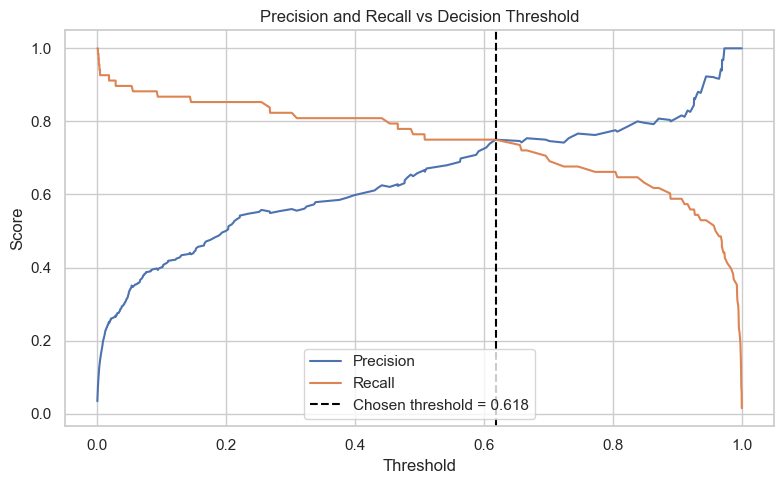

In [26]:
y_proba_best = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_threshold_idx = np.argmax(f1_scores) #finds the array index where f1 is highest.
best_threshold = thresholds[best_threshold_idx]

print(f"Default threshold (0.5) F1: {f1_score(y_test, y_proba_best >= 0.5):.4f}")
print(f"Tuned threshold ({best_threshold:.3f}) F1: {f1_scores[best_threshold_idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Chosen threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

<b>Evaluation at the chosen threshold</b>

              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.75      0.75      0.75        68

    accuracy                           0.98      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.98      0.98      0.98      2000



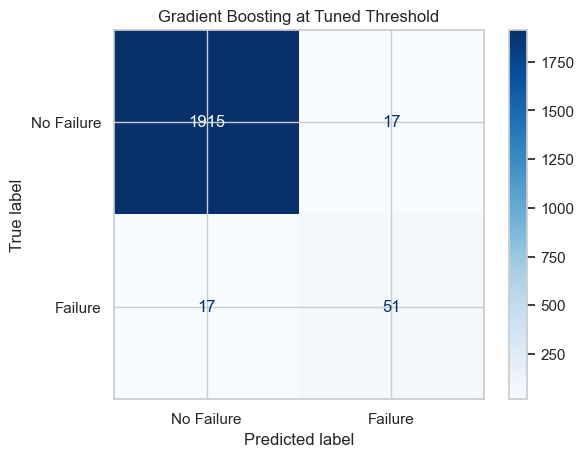

In [27]:
y_pred_final = (y_proba_best >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_final, target_names=['No Failure', 'Failure']))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure']).plot(cmap='Blues')
plt.title(f'{best_model_name} at Tuned Threshold')
plt.show()

### <b>Part 2 Refining the Winning Model (Gradient Boosting)</b>
Now that Gradient Boosting has been selected, I go deeper: a wider GBM-specific search, learning-curve-based tree count selection, refit on full training data, and a leak-free CV-tuned threshold.

<b>Focused hyperparameter search on GBM</b>

<i>60 iterations focused on one model beats 25 spread across three.</i>

In [ ]:
gbm_param_dist = {
    'n_estimators': [100, 200, 300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None],
}

gbm_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gbm_param_dist,
    n_iter=60,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
gbm_search.fit(X_train, y_train)
print(f"Best CV PR-AUC: {gbm_search.best_score_:.4f}")
print(f"Best params: {gbm_search.best_params_}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV PR-AUC: 0.9996
Best params: {'subsample': 1.0, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 6, 'learning_rate': 0.2}


<b>Learning curve to find the real stopping point</b>

<i>RandomizedSearchCV picks n_estimators from a fixed list , it can't tell if 300 was too many or too few. staged_predict_proba scores every boosting round from a single fit, showing exactly where validation performance peaks before the model starts overfitting.</i>

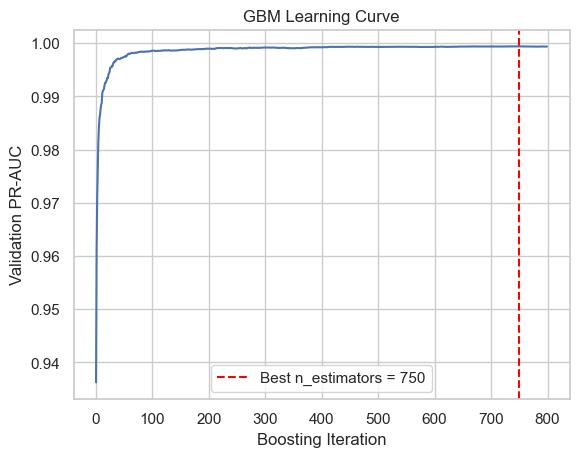

Optimal n_estimators: 750 (val PR-AUC: 0.9994)


In [29]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

best_params_no_n = {k: v for k, v in gbm_search.best_params_.items() if k != 'n_estimators'}
gbm_stage_check = GradientBoostingClassifier(**best_params_no_n, n_estimators=800, random_state=42)
gbm_stage_check.fit(X_tr, y_tr)

val_scores = [average_precision_score(y_val, proba[:, 1])
              for proba in gbm_stage_check.staged_predict_proba(X_val)]

best_n = np.argmax(val_scores) + 1
plt.plot(val_scores)
plt.axvline(best_n, color='red', linestyle='--', label=f'Best n_estimators = {best_n}')
plt.xlabel('Boosting Iteration'); plt.ylabel('Validation PR-AUC'); plt.legend()
plt.title('GBM Learning Curve')
plt.show()

print(f"Optimal n_estimators: {best_n} (val PR-AUC: {val_scores[best_n-1]:.4f})")

<b>Refitting the final model on full training data at the optimal tree count</b>

<i>The Code block above used a train/validation split to find the right stopping point , using which we refit on the full X_train (more data means better final model) this becomes the model to finally ship.</i>

In [30]:
best_model = GradientBoostingClassifier(**best_params_no_n, n_estimators=best_n, random_state=42)
best_model.fit(X_train, y_train)
best_model_name = 'Gradient Boosting (tuned)'

y_proba_best = best_model.predict_proba(X_test)[:, 1]
print(f"Final Test PR-AUC: {average_precision_score(y_test, y_proba_best):.4f}")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

Final Test PR-AUC: 0.8221
Final Test ROC-AUC: 0.9644


<b>CV-based threshold (not test-set-based) and final report</b>

<i>Picking the threshold on the test set leaks test information into a decision that affects test metrics , the test set stops being a clean estimate of real-world performance. Tuning it via out-of-fold CV predictions on training data keeps the test set honest.</i>

CV-tuned threshold: 0.885
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.75      0.74      0.74        68

    accuracy                           0.98      2000
   macro avg       0.87      0.86      0.87      2000
weighted avg       0.98      0.98      0.98      2000



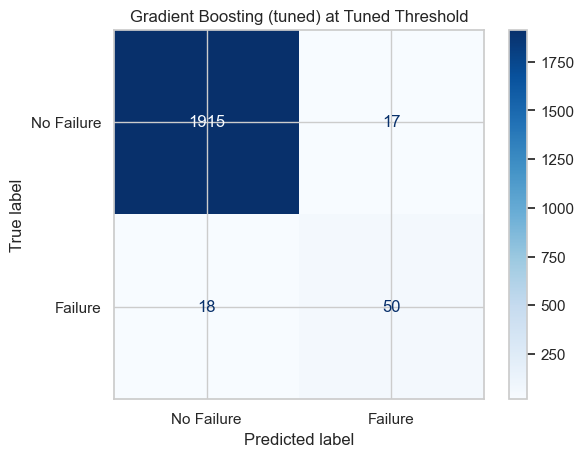

In [31]:
from sklearn.model_selection import cross_val_predict

y_train_proba_oof = cross_val_predict(best_model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_proba_oof)
f1s = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_threshold = thresholds[np.argmax(f1s)]

y_pred_final = (y_proba_best >= best_threshold).astype(int)
print(f"CV-tuned threshold: {best_threshold:.3f}")
print(classification_report(y_test, y_pred_final, target_names=['No Failure', 'Failure']))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure']).plot(cmap='Blues')
plt.title(f'{best_model_name} at Tuned Threshold')
plt.show()

<b>Saving the deployable bundle</b>

In [32]:
bundle = {
    'model': best_model,
    'model_name': best_model_name,
    'scaler': scaler,
    'label_encoder': label_encoder,
    'threshold': best_threshold,
    'feature_columns': X_train.columns.tolist()
}
joblib.dump(bundle, 'model_bundle.pkl')
print("Saved model_bundle.pkl")

Saved model_bundle.pkl
